In [1]:
from ase.build import fcc111, fcc100
from ase.calculators.espresso import Espresso, EspressoProfile
import numpy as np
import os; 
from ase.visualize import view
from ase.build import bulk

import re
from ase.io.trajectory import Trajectory
from ase.eos import EquationOfState
from ase.io import read
from ase.units import kJ

In [2]:
# Define pseudopotentials and input data for Quantum ESPRESSO
profile = EspressoProfile(
    command='mpirun -np 4 pw.x', pseudo_dir='./pseudos')
pseudopotentials = {'Cu': 'Cu.pbe-dn-kjpaw_psl.1.0.0.UPF'} # a dict!

input_data = {
    'control': {
        'calculation': 'scf',
        'verbosity': 'high',
    },
    'system': {
        'ecutwfc': 50,    # Plane-wave cutoff energy in Ry
        'ecutrho': 400,   # Charge density cutoff in Ry
        'occupations': 'smearing',
        'smearing': 'mp',
        'degauss': 0.02,  # Width of smearing in Ry
    },
    'electrons': {
        'conv_thr': 1e-6,  # Convergence threshold
    },
}
kpts = (8, 8, 8)  # k-point grid for the slab

In [3]:
calc = Espresso(profile=profile, pseudopotentials=pseudopotentials,
                tstress=True, tprnfor=True, kpts=kpts, input_data=input_data)

In [14]:
# Create a bulk FCC crystal for Cu
a_lat = 3.63 # Angstron
bulk_system = bulk('Cu', 'fcc', a=a_lat)  # cubic=True
view(bulk_system, viewer="ngl")

In [5]:
# work arround due to bug in ASE Espresso front end... but you could extract by hand. 
# next returns the first match and stops! 
# 
#total_energy = next(float(line.split('=')[1].strip().split()[0]) for line in open("espresso.pwo") if line.startswith("!")); 
#print(f"Total energy: {total_energy} Ry")


#os.rename("espresso.pwo", "espresso.pwo.cu_slab"); 


In [6]:
bulk_system.calc = calc

# Calculate bulk energy per atom
bulk_energy = bulk_system.get_potential_energy() / len(bulk_system)

In [7]:
print(f"Bulk energy per atom: {bulk_energy:.6f} eV")

Bulk energy per atom: -2899.285540 eV


In [8]:
n_atoms = len(bulk_system)


In [9]:
lat = bulk('Cu', 'fcc', a=3.62)
lat.calc = calc 
min_s = max_s = 0.1

cell = lat.get_cell() 
print(f"Cu unit cell: {cell}")
traj = Trajectory('cu-eos.traj', 'w')

for s in np.linspace((1-min_s), (1+max_s), 5):
    lat.set_cell(cell * s, scale_atoms=True)
    lat.get_potential_energy()
    traj.write(lat)

configs = read('cu-eos.traj@0:5')  # read all configurations
# Extract volumes and energies:
volumes = [c.get_volume() for c in configs]
energies = [c.get_potential_energy() for c in configs]
print(volumes, energies)
eos = EquationOfState(volumes, energies)
v0, e0, B = eos.fit()
print(min_s, v0, e0, B / kJ * 1.0e24, 'GPa')


Cu unit cell: Cell([[0.0, 1.81, 1.81], [1.81, 0.0, 1.81], [1.81, 1.81, 0.0]])
[8.645562378000001, 10.168023379750005, 11.859481999999998, 13.728832850250003, 15.784970542000005] [-2898.493519358288, -2899.112647322088, -2899.2846440848266, -2899.20519963329, -2898.9902303810363]
0.1 12.015662146342912 -2899.286473986742 141.18376263607598 GPa


In [10]:
a=pow(v0*4,1/3)
print(a)

3.6358216098763525


<Axes: title={'center': 'sj: E: -2899.286 eV, V: 12.016 Å$^3$, B: 141.184 GPa'}, xlabel='volume [Å$^3$]', ylabel='energy [eV]'>

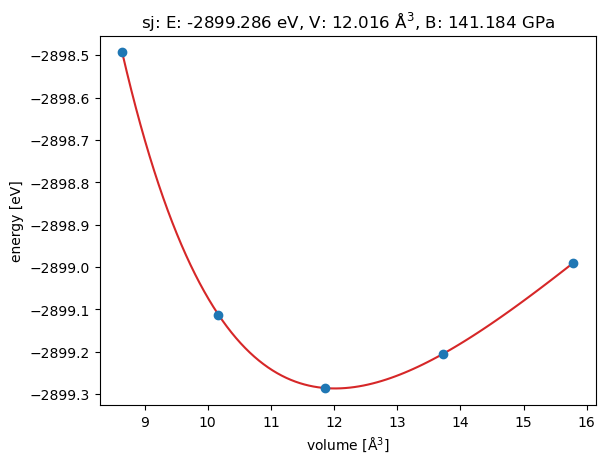

In [11]:
eos.plot('cu-eos.png')

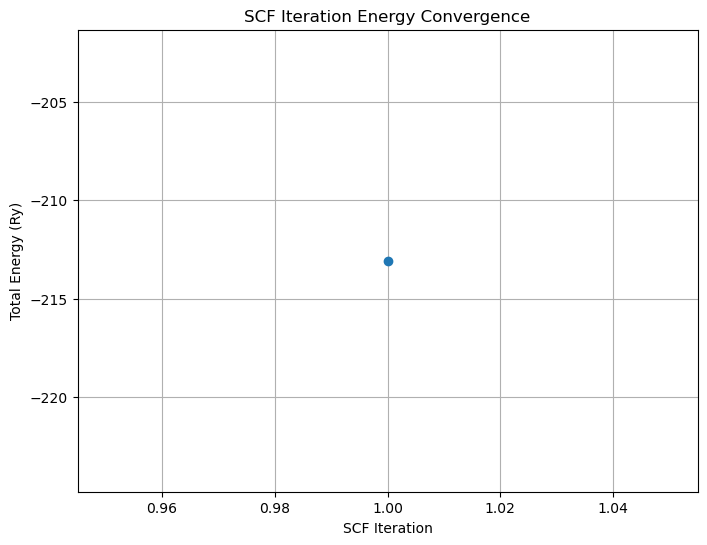

In [12]:
import matplotlib.pyplot as plt
scf_energies = []
with open("espresso.pwo", "r") as file:
    for line in file:
        match = re.search(r"!\s+total energy\s+=\s+(-?\d+\.\d+)", line)  # Final energy of each SCF cycle
        if match:
            scf_energies.append(float(match.group(1)))

# Plot SCF iteration energies
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(scf_energies) + 1), scf_energies, marker="o", linestyle="-")
plt.title("SCF Iteration Energy Convergence")
plt.xlabel("SCF Iteration")
plt.ylabel("Total Energy (Ry)")
plt.grid(True)
plt.show()